# CLASIFICACIÓN DE LAS CANCIONES DE TAYLOR SWIFT EN ALBUMS . B #

Lucía de Lamadrid y Paula de Blas

Aprendizaje automático 2023/2024

# 2. REDUCCION DE ETIQUETAS #

Los albums de folklore y evermore, fueron publicados en 2020-2021, durante la época del COVID-19 en la que la artista estaba experimentando con su sonido y composición, por lo que ambos se podrían juntar en una sola etiqueta debido a lo parecidos que son musicalmente y líricamente hablando.  Por lo tanto, a las canciones de ambos albums le ponemos la etiqueta: "folkmore". 
Además también vamos a eliminar el album Taylor Swift, ya que es el que menos observaciones tiene y el que más puede afectar a la precisión global.

In [512]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import re #to remove the special characters in the text
from sklearn.feature_extraction.text import CountVectorizer
##importing models of the day
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

In [513]:
df = pd.read_csv('data/songs_modif2.csv', header=0)
df
#cargamos el archivo csv que contiene las canciones con su letra perteneciente a cada album de la discografía de Taylor Swift

,Title,Album,Lyrics
0,22 (Taylor’s Version),Red (Taylor’s Version),It feels like a perfect night To dress up lik...
1,All Too Well (10 Minute Version) (Taylor’s Ver...,Red (Taylor’s Version),"I walked through the door with you, the air wa..."
2,All Too Well (Taylor’s Version),Red (Taylor’s Version),"I walked through the door with you, the air wa..."
3,Babe (Taylor’s Version),Red (Taylor’s Version),"What about your promises, promises? What abou..."
4,Begin Again (Taylor’s Version),Red (Taylor’s Version),Took a deep breath in the mirror He didn't li...
...,...,...,...
250,I Look in People’s Windows,The Tortured Poets Department,I had died the tiniest death I spied the catc...
251,The Prophecy,The Tortured Poets Department,Hand on the throttle Thought I caught lightni...
252,Cassandra,The Tortured Poets Department,I was in my new house placing daydreams Patch...
253,Peter,The Tortured Poets Department,"Forgive me, Peter My lost fearless leader In..."


In [514]:
import random
# enpleamos esta función para dividir las canciones en versos y así poder descomponer la complejidad de los datos y tener más observaciones asignadas a una sola etiqueta
def dividir_letras(letra, tamaño_trozo):
    versos = letra.splitlines()  # Divide la letra en versos utilizando diferentes tipos de saltos de línea
    cachitos = []
    for verso in versos:
        palabras = verso.split()  # Dividie el verso en palabras
        inicio = 0
        while inicio < len(palabras):
            fin = inicio + tamaño_trozo
            cachitos.append(" ".join(palabras[inicio:fin]))
            inicio = fin
    random.shuffle(cachitos)  # Mezclar los cachitos de la cancion forma aleatoria
    return cachitos



In [515]:
df["Album"]=df["Album"].replace("folklore","folkmore")
df["Album"]=df["Album"].replace("evermore","folkmore")
nuevo_df = df.assign(Lyrics=df['Lyrics'].apply(dividir_letras, tamaño_trozo=35)).explode('Lyrics')

# Resetear el índice del DataFrame resultante
nuevo_df.reset_index(drop=True, inplace=True)

# Mostrar el nuevo DataFrame
nuevo_df

,Title,Album,Lyrics
0,22 (Taylor’s Version),Red (Taylor’s Version),"about the heartbreaks It's time, oh-oh (Hey) I..."
1,22 (Taylor’s Version),Red (Taylor’s Version),of those nights We ditch the whole scene It fe...
2,22 (Taylor’s Version),Red (Taylor’s Version),We ditch the whole scene And end up dreamin' I...
3,22 (Taylor’s Version),Red (Taylor’s Version),"Uh-uh, uh-uh Yeah We're happy, free, confused,..."
4,22 (Taylor’s Version),Red (Taylor’s Version),sleepin' It feels like one of those nights (Tw...
...,...,...,...
2728,Robin,The Tortured Poets Department,the dragonflies above your bed You have a favo...
2729,Robin,The Tortured Poets Department,"in sweetness Way to go, tiger Higher and highe..."
2730,Robin,The Tortured Poets Department,"Long may you reign You're an animal, you are b..."
2731,Robin,The Tortured Poets Department,idea Buried down deep and out of your reach Th...


De esta forma hemos pasado de 255 observaciones a 2733

In [516]:
#pip install nltk
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [517]:
# eliminamos taylor swift, folklore y evermore  y añadimos folkmore
albumes_deseados = [
    'folkmore',
    'The Tortured Poets Department',
    'Speak Now (Taylor’s Version)',
    'Red (Taylor’s Version)',
    'nineteeneightynine (Taylor’s Version)  ',
    'Midnights (3am Edition)',
    'Lover',
    'Fearless (Taylor’s Version)',
    'reputation'
]

# Filtrar el DataFrame para quedarse solo con las filas que corresponden a los álbumes deseados
df_filtrado = nuevo_df[nuevo_df['Album'].isin(albumes_deseados)]

df_filtrado



,Title,Album,Lyrics
0,22 (Taylor’s Version),Red (Taylor’s Version),"about the heartbreaks It's time, oh-oh (Hey) I..."
1,22 (Taylor’s Version),Red (Taylor’s Version),of those nights We ditch the whole scene It fe...
2,22 (Taylor’s Version),Red (Taylor’s Version),We ditch the whole scene And end up dreamin' I...
3,22 (Taylor’s Version),Red (Taylor’s Version),"Uh-uh, uh-uh Yeah We're happy, free, confused,..."
4,22 (Taylor’s Version),Red (Taylor’s Version),sleepin' It feels like one of those nights (Tw...
...,...,...,...
2728,Robin,The Tortured Poets Department,the dragonflies above your bed You have a favo...
2729,Robin,The Tortured Poets Department,"in sweetness Way to go, tiger Higher and highe..."
2730,Robin,The Tortured Poets Department,"Long may you reign You're an animal, you are b..."
2731,Robin,The Tortured Poets Department,idea Buried down deep and out of your reach Th...


In [518]:
pattern = r'[^a-zA-Z0-9\s]'
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

def preprocess(text):
    text = text.lower()  # convertir a minúsculas
    clean_text = re.sub(pattern, '', text)  # eliminar caracteres no alfanuméricos
    tokens = word_tokenize(clean_text)  # tokenizar el texto limpio
    filtered_tokens = [word for word in tokens if word not in stop_words]  # eliminar stop words
    stemmed_tokens = [ps.stem(word) for word in filtered_tokens]  # aplicar el stemmer de Porter
    return ' '.join(stemmed_tokens)

In [519]:
df_filtrado["Lyrics"]=df_filtrado['Lyrics'].apply(preprocess)

df_filtrado

C:\Users\Asus\AppData\Local\Temp\ipykernel_29580\1975535251.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado["Lyrics"]=df_filtrado['Lyrics'].apply(preprocess)


,Title,Album,Lyrics
0,22 (Taylor’s Version),Red (Taylor’s Version),heartbreak time ohoh hey dont know im feelin t...
1,22 (Taylor’s Version),Red (Taylor’s Version),night ditch whole scene feel like one night wo...
2,22 (Taylor’s Version),Red (Taylor’s Version),ditch whole scene end dreamin instead sleepin ...
3,22 (Taylor’s Version),Red (Taylor’s Version),uhuh uhuh yeah happi free confus lone time mis...
4,22 (Taylor’s Version),Red (Taylor’s Version),sleepin feel like one night twentytwo look lik...
...,...,...,...
2728,Robin,The Tortured Poets Department,dragonfli bed favorit spot swing set room drea...
2729,Robin,The Tortured Poets Department,sweet way go tiger higher higher wilder lighte...
2730,Robin,The Tortured Poets Department,long may reign your anim bloodthirsti window p...
2731,Robin,The Tortured Poets Department,idea buri deep reach secret vow keep sweet way...


In [520]:
# Vectorization
cv = CountVectorizer(max_features=5000)
cv.fit(df_filtrado['Lyrics'])
trf = cv.transform(df_filtrado['Lyrics']) 
trf = trf.toarray()
X = trf

y = df_filtrado['Album']

y_uniq=list(set(y))
y_uniq


['Lover',
 'The Tortured Poets Department',
 'folkmore',
 'Speak Now (Taylor’s Version)',
 'Red (Taylor’s Version)',
 'Midnights (3am Edition)',
 'Fearless (Taylor’s Version)',
 'reputation',
 'nineteeneightynine (Taylor’s Version)  ']

In [521]:
album_unico=list(y_uniq)
albumes_a_numero = {album: numero for numero, album in enumerate(album_unico)}

albumes_a_numero #diccionario en el que se recoge la asociacion de cada label numerica a un album


{'Lover': 0,
 'The Tortured Poets Department': 1,
 'folkmore': 2,
 'Speak Now (Taylor’s Version)': 3,
 'Red (Taylor’s Version)': 4,
 'Midnights (3am Edition)': 5,
 'Fearless (Taylor’s Version)': 6,
 'reputation': 7,
 'nineteeneightynine (Taylor’s Version)  ': 8}

In [522]:
# Asignar los números a cada álbum en una nueva columna 'Album_Numero'
df_filtrado['Album_Numero'] = df_filtrado['Album'].map(albumes_a_numero)

y=df_filtrado['Album_Numero']

# Codificar la columna 'Album_Numero' usando LabelEncoder
le = LabelEncoder()
y_label = le.fit_transform(y)
y_label 


C:\Users\Asus\AppData\Local\Temp\ipykernel_29580\1769874298.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['Album_Numero'] = df_filtrado['Album'].map(albumes_a_numero)


array([4, 4, 4, ..., 1, 1, 1], dtype=int64)

In [523]:

X_train, X_test, y_train, y_test = train_test_split(X, y_label, test_size=0.2)

In [524]:
mnb = MultinomialNB() #empleamos Multinomial Naive Bayes como una primera aproximacion
mnb.fit(X_train, y_train)
y_preds = mnb.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_preds)) 

Accuracy: 0.6476793248945147


In [525]:
print("Classification Report:\n", classification_report(y_test, y_preds))

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.49      0.61        39
           1       0.65      0.54      0.59        69
           2       0.66      0.66      0.66        65
           3       0.59      0.69      0.64        52
           4       0.48      0.77      0.59        60
           5       0.69      0.51      0.59        35
           6       0.62      0.70      0.65        46
           7       0.77      0.62      0.69        48
           8       0.84      0.77      0.80        60

    accuracy                           0.65       474
   macro avg       0.68      0.64      0.65       474
weighted avg       0.67      0.65      0.65       474



In [526]:
from sklearn.ensemble import BaggingClassifier #le aplicamos bagging con intención de mejorar la accuracy
bggC = BaggingClassifier(MultinomialNB())
bggC.fit(X_train, y_train)
print('Exactitud - Accuracy: %.4f' % bggC.score(X_test, y_test)) # No hay un aumento significativo con bagging


Exactitud - Accuracy: 0.6603


In [527]:
album_unico=list(y_uniq)
albumes_a_numero = {album: numero for numero, album in enumerate(album_unico)}

albumes_a_numero #diccionario en el que se recoge la asociacion de cada label numerica a un album

{'Lover': 0,
 'The Tortured Poets Department': 1,
 'folkmore': 2,
 'Speak Now (Taylor’s Version)': 3,
 'Red (Taylor’s Version)': 4,
 'Midnights (3am Edition)': 5,
 'Fearless (Taylor’s Version)': 6,
 'reputation': 7,
 'nineteeneightynine (Taylor’s Version)  ': 8}

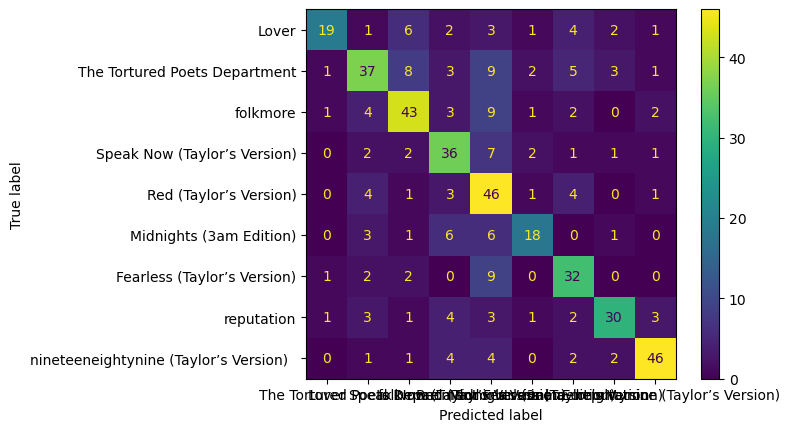

In [528]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Calculamos la matriz de confusión utilizando las etiquetas verdaderas (y_test) y las predicciones (y_pred)
cm = confusion_matrix(y_true=y_test, y_pred=y_preds)


cm_display = ConfusionMatrixDisplay(cm, display_labels=y_uniq).plot()


De esta forma hemos conseguido mejorar el accuracy de los albums, no obstante tal y como se ha observado en los wordclouds del cuaderno A., Taylor utiliza recurrentemente palabras como "know", "never", "now", que hacen que el entrenamiento sea confuso para el modelo. Se podría añadir estas palabras como stopwords, para mejorar el entrenamiento, no obstante también supondría un menor número de observaciones. Además no todos las canciones de un mismo álbum siguen una misma temática por lo que es dificil capturar la esencia lírica de cada album. 


# 3. OTROS MÉTODOS DE CLASIFICACIÓN # 

## SUPPORT VECTOR MACHINES ##

In [529]:
df = pd.read_csv('data/songs_modif2.csv', header=0)
df

,Title,Album,Lyrics
0,22 (Taylor’s Version),Red (Taylor’s Version),It feels like a perfect night To dress up lik...
1,All Too Well (10 Minute Version) (Taylor’s Ver...,Red (Taylor’s Version),"I walked through the door with you, the air wa..."
2,All Too Well (Taylor’s Version),Red (Taylor’s Version),"I walked through the door with you, the air wa..."
3,Babe (Taylor’s Version),Red (Taylor’s Version),"What about your promises, promises? What abou..."
4,Begin Again (Taylor’s Version),Red (Taylor’s Version),Took a deep breath in the mirror He didn't li...
...,...,...,...
250,I Look in People’s Windows,The Tortured Poets Department,I had died the tiniest death I spied the catc...
251,The Prophecy,The Tortured Poets Department,Hand on the throttle Thought I caught lightni...
252,Cassandra,The Tortured Poets Department,I was in my new house placing daydreams Patch...
253,Peter,The Tortured Poets Department,"Forgive me, Peter My lost fearless leader In..."


In [530]:
df["Album"]=df["Album"].replace("folklore","folkmore")
df["Album"]=df["Album"].replace("evermore","folkmore")
nuevo_df = df.assign(Lyrics=df['Lyrics'].apply(dividir_letras, tamaño_trozo=35)).explode('Lyrics')

# Resetear el índice del DataFrame resultante
nuevo_df.reset_index(drop=True, inplace=True)

In [531]:
# Filtrar el DataFrame para quedarse solo con las filas que corresponden a los álbumes deseados
df_filtrado = nuevo_df[nuevo_df['Album'].isin(albumes_deseados)]

df_filtrado

,Title,Album,Lyrics
0,22 (Taylor’s Version),Red (Taylor’s Version),"Uh-uh, uh-uh Yeah We're happy, free, confused,..."
1,22 (Taylor’s Version),Red (Taylor’s Version),bet you want to Everything will be alright if ...
2,22 (Taylor’s Version),Red (Taylor’s Version),dancin' like we'rе Twenty-two Twenty-two It se...
3,22 (Taylor’s Version),Red (Taylor’s Version),of those nights We ditch the whole scene It fe...
4,22 (Taylor’s Version),Red (Taylor’s Version),woah-oh-oh-oh) Twenty-two (Dancin' like) Twent...
...,...,...,...
2728,Robin,The Tortured Poets Department,the mean You'll learn to bounce back just like...
2729,Robin,The Tortured Poets Department,"in sweetness Way to go, tiger Higher and highe..."
2730,Robin,The Tortured Poets Department,idea Buried down deep and out of your reach Th...
2731,Robin,The Tortured Poets Department,lighter For you


In [532]:
df_filtrado["Lyrics"]=df_filtrado['Lyrics'].apply(preprocess)

df_filtrado

C:\Users\Asus\AppData\Local\Temp\ipykernel_29580\1975535251.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado["Lyrics"]=df_filtrado['Lyrics'].apply(preprocess)


,Title,Album,Lyrics
0,22 (Taylor’s Version),Red (Taylor’s Version),uhuh uhuh yeah happi free confus lone time mis...
1,22 (Taylor’s Version),Red (Taylor’s Version),bet want everyth alright alright keep dancin l...
2,22 (Taylor’s Version),Red (Taylor’s Version),dancin like wer twentytwo twentytwo seem like ...
3,22 (Taylor’s Version),Red (Taylor’s Version),night ditch whole scene feel like one night wo...
4,22 (Taylor’s Version),Red (Taylor’s Version),woahohohoh twentytwo dancin like twentytwo yea...
...,...,...,...
2728,Robin,The Tortured Poets Department,mean youll learn bounc back like trampolin wel...
2729,Robin,The Tortured Poets Department,sweet way go tiger higher higher wilder lighte...
2730,Robin,The Tortured Poets Department,idea buri deep reach secret vow keep sweet way...
2731,Robin,The Tortured Poets Department,lighter


In [533]:
y = df_filtrado['Album']

y_uniq=list(set(y))
y_uniq

['Lover',
 'The Tortured Poets Department',
 'folkmore',
 'Speak Now (Taylor’s Version)',
 'Red (Taylor’s Version)',
 'Midnights (3am Edition)',
 'Fearless (Taylor’s Version)',
 'reputation',
 'nineteeneightynine (Taylor’s Version)  ']

In [534]:
album_unico=list(y_uniq)
albumes_a_numero = {album: numero for numero, album in enumerate(album_unico)}

albumes_a_numero 

{'Lover': 0,
 'The Tortured Poets Department': 1,
 'folkmore': 2,
 'Speak Now (Taylor’s Version)': 3,
 'Red (Taylor’s Version)': 4,
 'Midnights (3am Edition)': 5,
 'Fearless (Taylor’s Version)': 6,
 'reputation': 7,
 'nineteeneightynine (Taylor’s Version)  ': 8}

In [535]:
cv = CountVectorizer(max_features=5000)
cv.fit(df_filtrado['Lyrics'])
trf = cv.transform(df_filtrado['Lyrics']) 
trf = trf.toarray()
X = trf

In [536]:
# Asignar los números a cada álbum en una nueva columna 'Album_Numero'
df_filtrado['Album_Numero'] = df_filtrado['Album'].map(albumes_a_numero)

y=df_filtrado['Album_Numero']

# Codificar la columna 'Album_Numero' usando LabelEncoder
le = LabelEncoder()
y_label = le.fit_transform(y)
y_label 

C:\Users\Asus\AppData\Local\Temp\ipykernel_29580\3025725905.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['Album_Numero'] = df_filtrado['Album'].map(albumes_a_numero)


array([4, 4, 4, ..., 1, 1, 1], dtype=int64)

In [537]:

X_train, X_test, y_train, y_test = train_test_split(X, y_label, test_size=0.2)

In [538]:
from sklearn.svm import SVC
#Las Support Vector Machines (SVM) son una excelente opción para la clasificación de texto debido a su capacidad para manejar 
#problemas de clasificación lineales y no lineales, y generalmente proporcionan buenos resultados.

# Separar los datos en conjuntos de entrenamiento y prueba
# Entrenar el modelo
model = SVC(kernel='linear')
model.fit(X_train, y_train)
# Hacer predicciones
y_pred = model.predict(X_test)


In [539]:
# Evaluar el modelo
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5928270042194093
Classification Report:
               precision    recall  f1-score   support

           0       0.40      0.56      0.47        32
           1       0.49      0.67      0.56        63
           2       0.58      0.49      0.53        72
           3       0.52      0.52      0.52        62
           4       0.60      0.69      0.64        64
           5       0.67      0.61      0.64        36
           6       0.73      0.59      0.65        54
           7       0.80      0.60      0.69        40
           8       0.76      0.63      0.69        51

    accuracy                           0.59       474
   macro avg       0.62      0.59      0.60       474
weighted avg       0.61      0.59      0.60       474



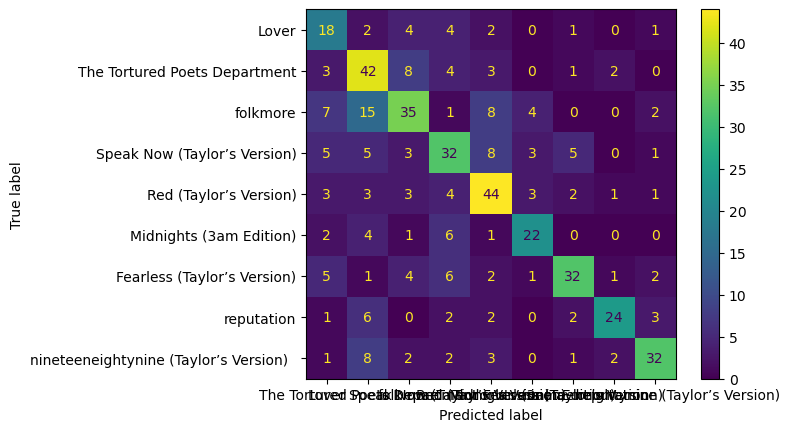

In [540]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Calculamos la matriz de confusión utilizando las etiquetas verdaderas (y_test) y las predicciones (y_pred)
cm = confusion_matrix(y_true=y_test, y_pred=y_pred)

# Obtenemos las etiquetas únicas de las clases


cm_display = ConfusionMatrixDisplay(cm, display_labels=y_uniq).plot()

Hemos obtenido una menor precisión al método de Multinomial NB por lo que, es ligeramente peor clasificador con este dataset.

## REDES LSTM (LONG SHORT TERM MEMORY) ##

In [541]:
#pip install tensorflow


In [542]:
df = pd.read_csv('data/songs_modif2.csv')
df.head()

,Title,Album,Lyrics
0,22 (Taylor’s Version),Red (Taylor’s Version),It feels like a perfect night To dress up lik...
1,All Too Well (10 Minute Version) (Taylor’s Ver...,Red (Taylor’s Version),"I walked through the door with you, the air wa..."
2,All Too Well (Taylor’s Version),Red (Taylor’s Version),"I walked through the door with you, the air wa..."
3,Babe (Taylor’s Version),Red (Taylor’s Version),"What about your promises, promises? What abou..."
4,Begin Again (Taylor’s Version),Red (Taylor’s Version),Took a deep breath in the mirror He didn't li...


In [543]:
df["Album"]=df["Album"].replace("folklore","folkmore")
df["Album"]=df["Album"].replace("evermore","folkmore")

In [544]:
nuevo_df = df.assign(Lyrics=df['Lyrics'].apply(dividir_letras, tamaño_trozo=35)).explode('Lyrics')

# Resetear el índice del DataFrame resultante
nuevo_df.reset_index(drop=True, inplace=True)

# Mostrar el nuevo DataFrame
nuevo_df

,Title,Album,Lyrics
0,22 (Taylor’s Version),Red (Taylor’s Version),woah-oh-oh-oh) Twenty-two (Dancin' like) Twent...
1,22 (Taylor’s Version),Red (Taylor’s Version),"Uh-uh, uh-uh Yeah We're happy, free, confused,..."
2,22 (Taylor’s Version),Red (Taylor’s Version),to you You don't know about me (You don't know...
3,22 (Taylor’s Version),Red (Taylor’s Version),bet you want to Everything will be alright if ...
4,22 (Taylor’s Version),Red (Taylor’s Version),"I gotta have you Ooh, oh Yeah, hey, yeah (Hey)..."
...,...,...,...
2728,Robin,The Tortured Poets Department,the mean You'll learn to bounce back just like...
2729,Robin,The Tortured Poets Department,idea Buried down deep and out of your reach Th...
2730,Robin,The Tortured Poets Department,the dragonflies above your bed You have a favo...
2731,Robin,The Tortured Poets Department,lighter For you


In [545]:
albumes_deseados = [
    'folkmore',
    'The Tortured Poets Department',
    'Speak Now (Taylor’s Version)',
    'Red (Taylor’s Version)',
    'nineteeneightynine (Taylor’s Version)  ',
    'Midnights (3am Edition)',
    'Lover',
    'Fearless (Taylor’s Version)',
    'reputation'
]

# Filtrar el DataFrame para quedarse solo con las filas que corresponden a los álbumes deseados
df_filtrado = nuevo_df[nuevo_df['Album'].isin(albumes_deseados)]
df_filtrado

,Title,Album,Lyrics
0,22 (Taylor’s Version),Red (Taylor’s Version),woah-oh-oh-oh) Twenty-two (Dancin' like) Twent...
1,22 (Taylor’s Version),Red (Taylor’s Version),"Uh-uh, uh-uh Yeah We're happy, free, confused,..."
2,22 (Taylor’s Version),Red (Taylor’s Version),to you You don't know about me (You don't know...
3,22 (Taylor’s Version),Red (Taylor’s Version),bet you want to Everything will be alright if ...
4,22 (Taylor’s Version),Red (Taylor’s Version),"I gotta have you Ooh, oh Yeah, hey, yeah (Hey)..."
...,...,...,...
2728,Robin,The Tortured Poets Department,the mean You'll learn to bounce back just like...
2729,Robin,The Tortured Poets Department,idea Buried down deep and out of your reach Th...
2730,Robin,The Tortured Poets Department,the dragonflies above your bed You have a favo...
2731,Robin,The Tortured Poets Department,lighter For you


In [546]:
# Verificar álbumes únicos en el conjunto de datos filtrado
y=df_filtrado["Album"]
y_uniq=set(y)
y_uniq=list(y_uniq)
y_uniq


['Lover',
 'The Tortured Poets Department',
 'folkmore',
 'Speak Now (Taylor’s Version)',
 'Red (Taylor’s Version)',
 'Midnights (3am Edition)',
 'Fearless (Taylor’s Version)',
 'reputation',
 'nineteeneightynine (Taylor’s Version)  ']

In [547]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Masking
from tensorflow.keras.optimizers import Adam

In [548]:
# Tokenización
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df_filtrado['Lyrics'])
total_words = len(tokenizer.word_index) + 1

input_sequences = tokenizer.texts_to_sequences(df_filtrado['Lyrics'])
max_sequence_len = max([len(x) for x in input_sequences])
input_sequences = pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre')

label_encoder = LabelEncoder()
label_encoder.fit(y_uniq)
df_filtrado['Album'] = label_encoder.transform(df_filtrado['Album'])
y = to_categorical(df_filtrado['Album'])

# Verificar el mapeo del label_encoder
print("Mapping del LabelEncoder:")
print({index: label for index, label in zip(range(len(label_encoder.classes_)), label_encoder.classes_)})
# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(input_sequences, y, test_size=0.2, random_state=42)

# Imprimir información sobre el procesamiento
print(f'Número total de palabras únicas: {total_words}')
print(f'Máxima longitud de secuencia: {max_sequence_len}')

Mapping del LabelEncoder:
{0: 'Fearless (Taylor’s Version)', 1: 'Lover', 2: 'Midnights (3am Edition)', 3: 'Red (Taylor’s Version)', 4: 'Speak Now (Taylor’s Version)', 5: 'The Tortured Poets Department', 6: 'folkmore', 7: 'nineteeneightynine (Taylor’s Version)  ', 8: 'reputation'}
Número total de palabras únicas: 4701
Máxima longitud de secuencia: 70


C:\Users\Asus\AppData\Local\Temp\ipykernel_29580\438330720.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['Album'] = label_encoder.transform(df_filtrado['Album'])


In [549]:
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense

# Construir el modelo
baseline_model = Sequential()
baseline_model.add(Embedding(input_dim=total_words, output_dim=150, input_length=max_sequence_len))
baseline_model.add(LSTM(150))
baseline_model.add(Dropout(0.1))
baseline_model.add(Dense(y.shape[1], activation='softmax'))
baseline_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Entrenar el modelo
baseline_model.fit(X_train, y_train, epochs=60, batch_size=32, validation_data=(X_test, y_test))

c:\Users\Asus\anaconda3\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/60


60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.1480 - loss: 2.1850 - val_accuracy: 0.2131 - val_loss: 2.1118
Epoch 2/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.3102 - loss: 1.9451 - val_accuracy: 0.2827 - val_loss: 1.8774
Epoch 3/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - accuracy: 0.4881 - loss: 1.4477 - val_accuracy: 0.3966 - val_loss: 1.7220
Epoch 4/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.7210 - loss: 0.8776 - val_accuracy: 0.5063 - val_loss: 1.6727
Epoch 5/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.8731 - loss: 0.4439 - val_accuracy: 0.5549 - val_loss: 1.5555
Epoch 6/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.9251 - loss: 0.2828 - val_accuracy: 0.5380 - val_loss: 1.5630
Epoch 7/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.9451 - loss: 0.2155 - val_accuracy: 0.5591 - val_loss: 1.7659
Epoch 8/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.9275 - loss: 0.2399 - val_accuracy: 0.5823 - val_loss: 1.

In [550]:
y_pred = baseline_model(X_test)
loss, accuracy = baseline_model.evaluate(X_test, y_test)
print(f'Loss: {loss}, Accuracy: {accuracy}')

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6324 - loss: 2.7451
Loss: 2.6365041732788086, Accuracy: 0.6392405033111572


In [551]:

y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Convertir las etiquetas numéricas de vuelta a nombres de álbumes
y_pred_labels = label_encoder.inverse_transform(y_pred_classes)
y_true_labels = label_encoder.inverse_transform(y_true_classes)

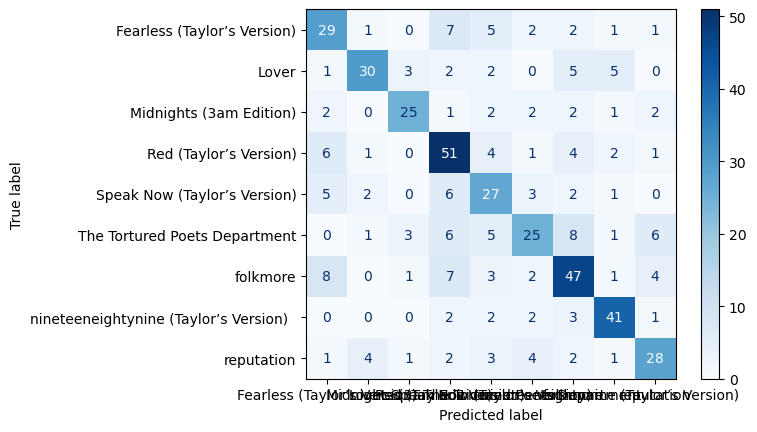

In [552]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
# Crear la matriz de confusión
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Visualizar la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')


Tal y como se ve en la matriz de confusión, obtenemos una precisión similar al método de Multinomial NB por lo que podemos concluir que también sería un buen clasificador para el dataset.